# Workforce Attrition Risk: Governance & Audit Review

This notebook is the full reproducible version of the workforce-attrition governance evidence pack generated with `hugiml-core`. 

**Audience:** HR governance, audit, compliance, workforce analytics, and business stakeholders.  
**Important use boundary:** The notebook supports workforce-support and governance review. It should not be used for adverse employment action, employee ranking, disciplinary decisions, promotion denial, or compensation decisions.


## 1. Reproducibility setup

The notebook expects the following CSV files in the same directory as this notebook:

- `nb11_workforce_attrition_data.csv`
- `nb11_workforce_attrition_metadata.csv`

The modeling API used below is `hugiml.HUGIMLClassifierNative` from the `hugiml-core` PyPI package.


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

BASE = Path.cwd()
DATA_PATH = BASE / "nb11_workforce_attrition_data.csv"
META_PATH = BASE / "nb11_workforce_attrition_metadata.csv"

required_files = [DATA_PATH, META_PATH]
missing = [str(p.name) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing required input file(s): {missing}. Place them beside this notebook.")

try:
    import hugiml
    print("hugiml import: OK")
except Exception as exc:
    raise RuntimeError(
        "hugiml-core is required. Install it with: pip install hugiml-core"
    ) from exc

print(f"Working directory: {BASE}")
print(f"Data file: {DATA_PATH.name}")
print(f"Metadata file: {META_PATH.name}")


hugiml import: OK
Working directory: /mnt/data/wa_extract
Data file: nb11_workforce_attrition_data.csv
Metadata file: nb11_workforce_attrition_metadata.csv


## 2. Load and inspect the data and governance metadata

The metadata file is treated as an audit input: it defines each column's modeling status, governance category, and stakeholder-facing description.


In [2]:
import pandas as pd
from IPython.display import display, HTML

df = pd.read_csv(DATA_PATH)
metadata = pd.read_csv(META_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Metadata shape: {metadata.shape[0]:,} rows x {metadata.shape[1]:,} columns")

display(df.head())
display(metadata.head(12))


Dataset shape: 1,470 rows x 35 columns
Metadata shape: 35 rows x 8 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


,column_name,pandas_dtype,role_or_use_status,governance_category,description,missing_count,unique_values,sample_values
0,Age,int64,Audit-only,Protected/sensitive audit attribute,Employee age; excluded from scoring and retain...,0,43,"41, 49, 37, 33, 27"
1,Attrition,object,Target,Outcome,"Binary target: Yes if employee left, No if emp...",0,2,"Yes, No"
2,BusinessTravel,object,Scoring + review,Medium proxy-risk / governance-sensitive,Business travel frequency; may reflect role de...,0,3,"Travel_Rarely, Travel_Frequently, Non-Travel"
3,DailyRate,int64,Scoring candidate,Business/HR context,Daily rate field; requires business justificat...,0,886,"1102, 279, 1373, 1392, 591"
4,Department,object,Scoring candidate,Business/HR context,Department assignment; may reflect organizatio...,0,3,"Sales, Research & Development, Human Resources"
5,DistanceFromHome,int64,Scoring + review,Medium proxy-risk / governance-sensitive,"Commute distance; may proxy geography, socioec...",0,29,"1, 8, 2, 3, 24"
6,Education,int64,Scoring candidate,Business/HR context,Education level; requires job-relatedness/busi...,0,5,"2, 1, 4, 3, 5"
7,EducationField,object,Scoring + review,Medium proxy-risk / governance-sensitive,Education field; may encode socioeconomic or o...,0,6,"Life Sciences, Other, Medical, Marketing, Tech..."
8,EmployeeCount,int64,Excluded,Identifier/constant,Constant field; excluded from scoring.,0,1,1
9,EmployeeNumber,int64,Excluded,Identifier/administrative,Employee identifier; excluded from scoring.,0,1470,"1, 2, 4, 5, 7"


In [3]:
class_balance = (
    df["Attrition"]
    .value_counts(dropna=False)
    .rename_axis("Attrition")
    .reset_index(name="employees")
)
class_balance["share"] = class_balance["employees"] / class_balance["employees"].sum()

metadata_status = (
    metadata["role_or_use_status"]
    .value_counts()
    .rename_axis("role_or_use_status")
    .reset_index(name="columns")
)

display(class_balance)
display(metadata_status)


,Attrition,employees,share
0,No,1233,0.838776
1,Yes,237,0.161224


,role_or_use_status,columns
0,Scoring + review,21
1,Scoring candidate,6
2,Excluded,4
3,Audit-only,3
4,Target,1


## 3. Define the reusable pipeline

The next cell contains the reusable functions from the companion Python script, with the notebook retaining intermediate objects so they can be inspected directly. The functions produce four artifacts:

- `workforce_attrition_governance_stakeholder_aligned.html`
- `workforce_feature_register_actual.csv`
- `workforce_pattern_inventory_actual.csv`
- `workforce_group_threshold_sensitivity_actual.csv`


In [4]:
"""
Workforce Attrition Risk: Governance & Audit Review

"""

from __future__ import annotations

from pathlib import Path
from matplotlib.patches import Circle
import base64
import html
import io
import warnings

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

try:
    from hugiml import HUGIMLClassifierNative
except Exception as exc:  
    raise RuntimeError(
        "hugiml-core is required for this notebook/script. Install with `pip install hugiml-core`. "
        "The import namespace is `hugiml`."
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

BASE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_PATH = BASE / "nb11_workforce_attrition_data.csv"
META_PATH = BASE / "nb11_workforce_attrition_metadata.csv"
HTML_OUT = BASE / "workforce_attrition_governance_stakeholder_aligned.html"
FEATURE_REGISTER_OUT = BASE / "workforce_feature_register_actual.csv"
PATTERN_INVENTORY_OUT = BASE / "workforce_pattern_inventory_actual.csv"
THRESHOLD_SENSITIVITY_OUT = BASE / "workforce_group_threshold_sensitivity_actual.csv"

RANDOM_STATE = 42


def fmt_pct(x: float) -> str:
    return f"{100 * x:.1f}%"


def fig_to_base64(fig) -> str:
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=165, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode("utf-8")


def build_metadata(df: pd.DataFrame) -> pd.DataFrame:
    if META_PATH.exists():
        return pd.read_csv(META_PATH)
    rows = []
    for col in df.columns:
        rows.append({
            "column_name": col,
            "pandas_dtype": str(df[col].dtype),
            "role_or_use_status": "Target" if col == "Attrition" else "Review required",
            "governance_category": "Outcome" if col == "Attrition" else "To be classified",
            "description": "Binary target" if col == "Attrition" else "Requires governance review",
            "missing_count": int(df[col].isna().sum()),
            "unique_values": int(df[col].nunique(dropna=True)),
            "sample_values": ", ".join(map(str, df[col].dropna().unique()[:5])),
        })
    metadata = pd.DataFrame(rows)
    metadata.to_csv(META_PATH, index=False)
    return metadata


def build_feature_register(metadata: pd.DataFrame) -> pd.DataFrame:
    feature_register = metadata[metadata["role_or_use_status"] != "Target"].copy()
    feature_register = feature_register.rename(columns={
        "column_name": "Feature",
        "role_or_use_status": "Status",
        "governance_category": "Governance category",
        "description": "Audit treatment",
    })[["Feature", "Status", "Governance category", "Audit treatment"]]
    feature_register.to_csv(FEATURE_REGISTER_OUT, index=False)
    return feature_register


def modeling_and_audit_views(df: pd.DataFrame):
    work = df.copy()
    work["AttritionFlag"] = (work["Attrition"] == "Yes").astype(int)
    work["AgeBand"] = pd.cut(work["Age"], bins=[17, 29, 39, 49, 60], labels=["18-29", "30-39", "40-49", "50+"])

    excluded_from_scoring = [
        "Attrition", "AttritionFlag", "EmployeeNumber", "EmployeeCount", "Over18", "StandardHours",
        "Age", "Gender", "MaritalStatus", "AgeBand",
    ]
    feature_cols = [c for c in work.columns if c not in excluded_from_scoring]
    X = work[feature_cols]
    y = work["AttritionFlag"]
    return work, X, y, feature_cols


def train_hugiml(X: pd.DataFrame, y: pd.Series):
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, X.index, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    clf = HUGIMLClassifierNative(B=8, L=1, G=1e-4, topK=80, adaptive_binning=True, verbose=False, n_jobs=1)
    clf.fit(X_train, y_train)
    risk_score = clf.predict_proba(X_test)[:, 1]
    return clf, X_train, X_test, y_train, y_test, idx_train, idx_test, risk_score


def extract_rule_inventory(clf) -> pd.DataFrame:
    fi = clf.feature_importances().copy()
    if "abs_coefficient" not in fi.columns:
        fi["abs_coefficient"] = fi["coefficient"].abs()

    def feature_name(pattern: str) -> str:
        pattern = str(pattern)
        if "=" in pattern:
            return pattern.split("=")[0]
        if "[" in pattern:
            return pattern.split("[")[0]
        return pattern

    risk_map = {
        "OverTime": ("High", "Overtime can reflect workload or managerial practice; use only to trigger support, not punitive action."),
        "MonthlyIncome": ("High", "Compensation is organizationally assigned and can reflect structural inequality."),
        "JobLevel": ("High", "Job level is linked to career-stage and compensation; monitor age/tenure proxy risk."),
        "JobRole": ("Medium", "Role effects may reflect organizational conditions or unequal career ladders."),
        "EnvironmentSatisfaction": ("Medium", "Survey-derived sentiment is useful for support but sensitive in employee monitoring."),
        "JobSatisfaction": ("Medium", "Workplace sentiment should be used for support, not individual penalty."),
        "TotalWorkingYears": ("Medium", "Experience/tenure may proxy age or career stage."),
        "EducationField": ("Medium", "Education field may encode socioeconomic or occupational segregation patterns."),
        "NumCompaniesWorked": ("Medium", "Mobility history may proxy age, career stage, or labor-market access."),
        "StockOptionLevel": ("Medium", "Compensation structure may reflect level, role allocation, or inequality."),
        "YearsWithCurrManager": ("Medium", "Manager tenure may reflect organizational placement and manager effects."),
        "DistanceFromHome": ("Medium", "Commute distance may proxy geography, socioeconomic status, caregiving constraints."),
        "BusinessTravel": ("Medium", "Travel requirements may create caregiver/disability accommodation concerns."),
        "YearsAtCompany": ("Medium", "Tenure may proxy age or career stage."),
        "YearsInCurrentRole": ("Medium", "Role tenure may proxy age/career stage and internal mobility constraints."),
        "YearsSinceLastPromotion": ("Medium", "Promotion history may reflect structural career progression inequities."),
        "WorkLifeBalance": ("Medium", "Work-life balance signal requires accommodation and caregiver-sensitivity review."),
    }

    risks, notes, directions = [], [], []
    for _, row in fi.iterrows():
        feat = feature_name(row["pattern"])
        risk, note = risk_map.get(feat, ("Low", "Standard job-context review; confirm business justification."))
        risks.append(risk)
        notes.append(note)
        directions.append("Increases attrition-risk score" if row["coefficient"] > 0 else "Lowers attrition-risk score")
    fi["Governance risk"] = risks
    fi["Audit interpretation"] = notes
    fi["Direction"] = directions
    fi.to_csv(PATTERN_INVENTORY_OUT, index=False)
    return fi


def build_audit_frame(work: pd.DataFrame, idx_test, y_test, risk_score) -> pd.DataFrame:
    audit = work.loc[idx_test].copy().reset_index(drop=True)
    audit["actual_attrition"] = np.asarray(y_test)
    audit["risk_score"] = risk_score
    for top in [10, 20, 30]:
        cutoff = np.quantile(audit["risk_score"], 1 - top / 100)
        audit[f"review_top_{top}"] = (audit["risk_score"] >= cutoff).astype(int)
    return audit


def group_table(audit: pd.DataFrame, group: str, flag: str = "review_top_20") -> pd.DataFrame:
    rows = []
    for g, sub in audit.groupby(group, observed=False):
        if len(sub) == 0:
            continue
        actual_positive = sub[sub["actual_attrition"] == 1]
        rows.append({
            group: str(g),
            "employees": len(sub),
            "actual_attrition_rate": sub["actual_attrition"].mean(),
            "avg_risk_score": sub["risk_score"].mean(),
            "review_rate": sub[flag].mean(),
            "miss_rate_among_actual_attriters": (1 - actual_positive[flag]).mean() if len(actual_positive) else np.nan,
        })
    out = pd.DataFrame(rows)
    mx = out["review_rate"].max()
    mn = out["review_rate"].min()
    out["review_rate_ratio_vs_max"] = out["review_rate"] / mx if mx else np.nan
    out["review_rate_gap_vs_min"] = out["review_rate"] - mn
    return out.sort_values("review_rate", ascending=False)


def threshold_sensitivity(audit: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for group in ["Gender", "AgeBand", "MaritalStatus"]:
        for top in [10, 20, 30]:
            flag = f"review_top_{top}"
            tbl = group_table(audit, group, flag)
            high = tbl["review_rate"].max()
            low = tbl["review_rate"].min()
            rows.append({
                "Policy": f"Top {top}% review group",
                "Group": group.replace("AgeBand", "Age group").replace("MaritalStatus", "Marital status"),
                "Highest review rate": high,
                "Lowest review rate": low,
                "Highest-lowest gap": high - low,
                "Lowest / highest ratio": low / high if high else np.nan,
            })
    out = pd.DataFrame(rows)
    out.to_csv(THRESHOLD_SENSITIVITY_OUT, index=False)
    return out


def make_charts(work: pd.DataFrame, audit: pd.DataFrame, threshold_tbl: pd.DataFrame) -> dict[str, str]:
    plt.rcParams.update({"font.size": 9, "axes.titlesize": 11, "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8})
    images = {}

    counts = work["Attrition"].value_counts().reindex(["No", "Yes"])
    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    wedges, _ = ax.pie(counts.values, startangle=90, wedgeprops=dict(width=0.38))
    ax.add_artist(Circle((0, 0), 0.45, color="white"))
    ax.text(0, 0.08, f"{counts['Yes']}", ha="center", va="center", fontsize=18, fontweight="bold")
    ax.text(0, -0.10, "employees left", ha="center", va="center", fontsize=9)
    ax.set_title("Observed workforce outcome")
    ax.legend(wedges, [f"Stayed ({counts['No']}, {100*counts['No']/counts.sum():.1f}%)", f"Left ({counts['Yes']}, {100*counts['Yes']/counts.sum():.1f}%)"], loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=8)
    images["outcome"] = fig_to_base64(fig)

    segments = []
    for grp_name, order, label in [("OverTime", ["No", "Yes"], "Overtime"), ("MaritalStatus", ["Married", "Single", "Divorced"], "Marital status"), ("Gender", ["Female", "Male"], "Gender")]:
        rates = work.groupby(grp_name, observed=False)["AttritionFlag"].mean().reindex(order)
        counts = work.groupby(grp_name, observed=False).size().reindex(order)
        for category, rate, n in zip(order, rates.values, counts.values):
            segments.append((label, category, rate, n))
    plot_df = pd.DataFrame(segments, columns=["SegmentType", "Category", "Rate", "Count"])
    positions, y, last_type = [], 0, None
    for _, row in plot_df.iterrows():
        if last_type is not None and row["SegmentType"] != last_type:
            y += 0.75
        positions.append(y)
        y += 1
        last_type = row["SegmentType"]
    plot_df["y"] = positions
    fig, ax = plt.subplots(figsize=(6.7, 3.55))
    ax.hlines(plot_df["y"], 0, plot_df["Rate"], linewidth=2, alpha=0.6)
    ax.scatter(plot_df["Rate"], plot_df["y"], s=60)
    ax.set_yticks(plot_df["y"])
    ax.set_yticklabels([f"{a}: {b}" for a, b in zip(plot_df["SegmentType"], plot_df["Category"])])
    ax.set_xlabel("Share who left")
    ax.set_title("Observed attrition across key employee segments")
    ax.grid(axis="x", alpha=0.22)
    ax.set_xlim(0, max(0.34, plot_df["Rate"].max()+0.06))
    ax.invert_yaxis()
    for _, r in plot_df.iterrows():
        ax.text(r["Rate"] + 0.007, r["y"], f"{100*r['Rate']:.1f}% (n={int(r['Count'])})", va="center", fontsize=7.5)
    images["segments"] = fig_to_base64(fig)

    grp = work.groupby("JobRole", observed=False)["AttritionFlag"].agg(["mean", "count"]).sort_values("mean", ascending=True)
    fig, ax = plt.subplots(figsize=(7.0, 3.7))
    y = np.arange(len(grp))
    ax.hlines(y, 0, grp["mean"], lw=2, alpha=0.65)
    ax.scatter(grp["mean"], y, s=55)
    ax.set_yticks(y)
    ax.set_yticklabels(grp.index)
    ax.set_xlabel("Share who left")
    ax.set_title("Observed attrition by role")
    ax.grid(axis="x", alpha=0.2)
    ax.set_xlim(0, max(0.42, grp["mean"].max()+0.08))
    for yi, rate, cnt in zip(y, grp["mean"], grp["count"]):
        ax.text(rate + 0.004, yi, f"{100*rate:.1f}% (n={cnt})", va="center", fontsize=7.2)
    images["roles"] = fig_to_base64(fig)

    grp = work.groupby("AgeBand", observed=False)["AttritionFlag"].agg(["mean", "count"]).reindex(["18-29", "30-39", "40-49", "50+"])
    fig, ax1 = plt.subplots(figsize=(5.25, 3.35))
    ax1.plot(grp.index.astype(str), grp["mean"], marker="o", linewidth=2.1)
    ax1.fill_between(range(len(grp)), grp["mean"].values, alpha=0.15)
    ax1.set_ylim(0, max(0.32, grp["mean"].max()+0.05))
    ax1.set_ylabel("Share who left")
    ax1.set_title("Attrition by age group")
    ax1.grid(axis="y", alpha=0.2)
    ax2 = ax1.twinx()
    ax2.bar(grp.index.astype(str), grp["count"], alpha=0.25)
    ax2.set_ylabel("Employees")
    for i, val in enumerate(grp["mean"].values):
        ax1.text(i, val + 0.012, f"{100*val:.1f}%", ha="center", fontsize=8)
    images["age"] = fig_to_base64(fig)

    metrics = [("MonthlyIncome", "Monthly income"), ("YearsAtCompany", "Company tenure"), ("TotalWorkingYears", "Career experience"), ("DistanceFromHome", "Commute distance")]
    mat, labels, texts = [], [], []
    for col, label in metrics:
        binned = pd.qcut(work[col], q=5, duplicates="drop")
        grp = work.groupby(binned, observed=False)["AttritionFlag"].mean()
        mat.append(grp.values)
        labels.append(label)
        texts.append([f"{100*v:.1f}%" for v in grp.values])
    mat = np.array(mat)
    fig, ax = plt.subplots(figsize=(7.2, 3.95))
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(["Lowest", "Low-mid", "Middle", "High-mid", "Highest"])
    ax.set_title("Attrition concentration across employee groups")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, texts[i][j], ha="center", va="center", fontsize=8)
    cbar = fig.colorbar(im, ax=ax, shrink=0.84)
    cbar.set_label("Attrition rate")
    images["numeric_view"] = fig_to_base64(fig)

    pivot = threshold_tbl.pivot(index="Group", columns="Policy", values="Highest-lowest gap").loc[["Gender", "Age group", "Marital status"]]
    fig, ax = plt.subplots(figsize=(5.9, 3.05))
    im = ax.imshow(pivot.values, aspect="auto", cmap="coolwarm")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=12, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Review-rate differences across groups")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{100*pivot.iloc[i,j]:.1f} pts", ha="center", va="center", fontsize=8)
    cbar = fig.colorbar(im, ax=ax, shrink=0.82)
    cbar.set_label("Highest minus lowest")
    images["review_gap"] = fig_to_base64(fig)

    return images


def build_html(work, fi, feature_register, threshold_tbl, images):
    n = len(work)
    attr_cnt = int(work["AttritionFlag"].sum())
    attr_rate = work["AttritionFlag"].mean()
    overtime_rates = work.groupby("OverTime")["AttritionFlag"].mean()
    ot_yes, ot_no = overtime_rates["Yes"], overtime_rates["No"]
    age_rates = work.groupby("AgeBand", observed=False)["AttritionFlag"].mean().reindex(["18-29", "30-39", "40-49", "50+"])
    low_age, high_age = age_rates.idxmax(), age_rates.idxmin()
    jobrole_grp = work.groupby("JobRole", observed=False)["AttritionFlag"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    jobrole_top = jobrole_grp.iloc[0]
    q_income = work.groupby(pd.qcut(work["MonthlyIncome"], 5, duplicates="drop"), observed=False)["AttritionFlag"].mean()
    q_tenure = work.groupby(pd.qcut(work["YearsAtCompany"], 5, duplicates="drop"), observed=False)["AttritionFlag"].mean()

    status_counts = feature_register["Status"].value_counts().to_dict()
    sensitivity = feature_register[feature_register["Status"].isin(["Audit-only", "Excluded", "Scoring + review"])].copy().head(20)

    pos_patterns = fi.sort_values("coefficient", ascending=False).head(4)
    neg_patterns = fi.sort_values("coefficient", ascending=True).head(4)

    def esc(x): return html.escape(str(x))
    def rows_from_df(dframe, pct_cols=None):
        pct_cols = pct_cols or []
        rows = []
        for _, r in dframe.iterrows():
            vals = []
            for c, v in r.items():
                if c in pct_cols and pd.notna(v):
                    vals.append(f"{100*v:.1f}%")
                elif isinstance(v, float):
                    vals.append(f"{v:.3f}")
                else:
                    vals.append(str(v))
            rows.append("<tr>" + "".join(f"<td>{esc(v)}</td>" for v in vals) + "</tr>")
        return "\n".join(rows)

    def rule_items(dfsub, kind):
        label = "Higher attrition indication" if kind == "positive" else "Lower attrition indication"
        out = []
        for _, row in dfsub.iterrows():
            out.append(f"""
            <div class='rule-card {kind}'>
              <div class='rule-top'><strong>{esc(row['pattern'])}</strong><span>{row['coefficient']:+.3f}</span></div>
              <div class='rule-meta'>{label} · Coverage: {100*row['support']:.1f}% · Sensitivity: {esc(row['Governance risk'])}</div>
              <div class='rule-note'>{esc(row['Audit interpretation'])}</div>
            </div>
            """)
        return "\n".join(out)

    threshold_display = threshold_tbl.copy()
    for c in ["Highest review rate", "Lowest review rate", "Highest-lowest gap"]:
        threshold_display[c] = threshold_display[c].map(lambda x: f"{100*x:.1f}%")
    threshold_display["Lowest / highest ratio"] = threshold_display["Lowest / highest ratio"].map(lambda x: f"{x:.2f}")

    feature_rows = rows_from_df(sensitivity)
    threshold_rows = rows_from_df(threshold_display)

    summary_bullets = [
        f"Observed attrition is <strong>{fmt_pct(attr_rate)}</strong> ({attr_cnt} of {n} employees).",
        f"The strongest workforce split is <strong>overtime</strong>: {fmt_pct(ot_yes)} attrition with overtime versus {fmt_pct(ot_no)} without overtime.",
        f"The highest age-group attrition appears in <strong>{low_age}</strong> at {fmt_pct(age_rates.max())}, compared with {fmt_pct(age_rates.min())} in {high_age}.",
        f"The shortest company-tenure group shows {fmt_pct(q_tenure.iloc[0])} attrition versus {fmt_pct(q_tenure.iloc[-1])} in the longest-tenure group.",
        f"The lowest monthly-income group shows {fmt_pct(q_income.iloc[0])} attrition versus {fmt_pct(q_income.iloc[-1])} in the highest income group.",
        f"<strong>{esc(jobrole_grp.index[0])}</strong> has the highest role-level attrition at {fmt_pct(jobrole_top['mean'])} (n={int(jobrole_top['count'])}).",
    ]

    css = """
    :root{--bg1:#f4efe8;--bg2:#e2d5c8;--ink:#2c2925;--muted:#665d55;--accent:#7b4f2f;--panel:#fff;--line:#e7ddd3;--blue:#edf4f8;--amber:#fcf1df;--green:#f1f6ee;--red:#b4533d;--olive:#5c784e}*{box-sizing:border-box}body{margin:0;font-family:'Segoe UI',Tahoma,Verdana,sans-serif;line-height:1.44;color:var(--ink);background:linear-gradient(135deg,var(--bg1),var(--bg2));padding:16px}.container{max-width:1240px;margin:0 auto;background:var(--panel);padding:26px 30px 32px;border-radius:14px;box-shadow:0 12px 30px rgba(0,0,0,.10)}h1{margin:0 0 6px;color:#4c3321;font-size:2.18rem}.subtitle{color:var(--muted);font-size:1.02rem;font-style:italic;margin:0 0 16px}h2{margin:24px 0 12px;color:#58391f;font-size:1.36rem;padding:8px 12px;border-left:5px solid var(--accent);background:linear-gradient(to right,#f6ece1,transparent)}h3{margin:14px 0 8px;color:#5e4330;font-size:1.04rem}p{margin:7px 0}.callout{padding:12px 14px;border-radius:10px;border-left:5px solid var(--accent);margin:12px 0}.context{background:var(--blue);border-left-color:#527088}.caution{background:var(--amber);border-left-color:#b7791f}.insight{background:var(--green);border-left-color:#6f8f55}.cards{display:grid;grid-template-columns:repeat(6,1fr);gap:10px;margin:12px 0 8px}.card{background:linear-gradient(180deg,#fff,#fbf8f5);border:1px solid var(--line);border-radius:11px;padding:12px;box-shadow:0 2px 8px rgba(0,0,0,.035)}.card h4{margin:0 0 4px;color:#6b5e51;font-size:.76rem;text-transform:uppercase;letter-spacing:.28px}.card .value{font-size:1.48rem;font-weight:700;color:#4f3828;line-height:1.1}.card p{margin:4px 0 0;color:var(--muted);font-size:.84rem}.grid-2{display:grid;grid-template-columns:1fr 1fr;gap:14px;align-items:start}.figure{background:#fff;border:1px solid var(--line);border-radius:12px;padding:10px 10px 8px;box-shadow:0 2px 8px rgba(0,0,0,.035)}.figure img{width:100%;height:auto;display:block;border-radius:7px}.caption{margin-top:5px;color:var(--muted);font-size:.84rem}.table-wrap{overflow-x:auto;background:#fff;border:1px solid var(--line);border-radius:12px;padding:7px 8px 0;box-shadow:0 2px 8px rgba(0,0,0,.035)}table{width:100%;border-collapse:collapse;margin:2px 0 8px;background:#fff}th{background:#76502e;color:#fff;padding:8px;text-align:left;font-size:.82rem;white-space:nowrap}td{padding:7px 8px;border-bottom:1px solid #eee4db;vertical-align:top;font-size:.83rem}tr:nth-child(even) td{background:#fcfaf8}ul.insights{margin:0;padding-left:19px}ul.insights li{margin:6px 0}.rule-columns{display:grid;grid-template-columns:1fr 1fr;gap:12px}.rule-list{background:#fff;border:1px solid var(--line);border-radius:12px;padding:10px;box-shadow:0 2px 8px rgba(0,0,0,.035)}.rule-card{padding:8px 9px;border-radius:9px;background:#fbf9f7;margin:7px 0;border-left:4px solid var(--accent)}.rule-card.positive{border-left-color:var(--red)}.rule-card.negative{border-left-color:var(--olive)}.rule-top{display:flex;justify-content:space-between;gap:8px}.rule-top span{font-weight:700;white-space:nowrap;color:#4c3726}.rule-meta{color:var(--muted);font-size:.78rem;margin-top:2px}.rule-note{font-size:.83rem;margin-top:3px}.feature-summary{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:10px}.pill{background:#fbf8f4;border:1px solid var(--line);border-radius:10px;padding:9px 11px}.pill strong{font-size:1.12rem;color:#4f3828;display:block}.small-note{font-size:.81rem;color:var(--muted)}.footer-note{margin-top:20px;padding-top:12px;border-top:1px solid var(--line);color:var(--muted);font-size:.84rem}.badge{display:inline-block;padding:4px 10px;border-radius:999px;background:#f1e6d8;color:#69482a;font-size:.76rem;font-weight:600;margin-right:6px}.stack{display:grid;grid-template-rows:auto auto;gap:12px}.wide-view img{max-height:420px;object-fit:contain}@media(max-width:1100px){.cards{grid-template-columns:repeat(3,1fr)}.feature-summary{grid-template-columns:repeat(2,1fr)}}@media(max-width:850px){.grid-2,.rule-columns{grid-template-columns:1fr}.cards{grid-template-columns:repeat(2,1fr)}.container{padding:22px}}
    """

    html_doc = f"""<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8"><meta name="viewport" content="width=device-width, initial-scale=1.0"><title>Workforce Attrition Risk: Governance & Audit Review</title><style>{css}</style></head><body><div class="container">
    <h1>Workforce Attrition Risk: Governance & Audit Review</h1>
    <p class="subtitle">Stakeholder-facing review of workforce attrition patterns, employee-segment impacts, and transparent rule evidence using actual IBM HR data</p>
    <div class="callout context"><strong>Purpose of this review:</strong> Assess what the data and transparent model rules reveal about workforce attrition risk, where group differences appear, and which variables require governance attention. The report is written for HR governance, audit, compliance, and business stakeholders rather than ML engineering teams.</div>
    <h2>Key Findings for Governance and Audit Stakeholders</h2>
    <div class="cards"><div class="card"><h4>Dataset reviewed</h4><div class="value">{n:,}</div><p>Employee records</p></div><div class="card"><h4>Observed attrition</h4><div class="value">{fmt_pct(attr_rate)}</div><p>{attr_cnt} employees left</p></div><div class="card"><h4>Overtime difference</h4><div class="value">{100*(ot_yes-ot_no):.1f} pts</div><p>{fmt_pct(ot_yes)} vs {fmt_pct(ot_no)}</p></div><div class="card"><h4>Early tenure concern</h4><div class="value">{fmt_pct(q_tenure.iloc[0])}</div><p>Shortest tenure group</p></div><div class="card"><h4>Income gradient</h4><div class="value">{fmt_pct(q_income.iloc[0])}</div><p>Lowest income group</p></div><div class="card"><h4>Highest role segment</h4><div class="value">{fmt_pct(jobrole_top['mean'])}</div><p>{esc(jobrole_grp.index[0])}</p></div></div>
    <div class="callout insight"><ul class="insights">{''.join(f'<li>{b}</li>' for b in summary_bullets)}</ul></div>
    <h2>Business Context and Data Scope</h2><div class="grid-2"><div><div class="callout caution"><strong>Decision context:</strong> The outcome being studied is voluntary employee attrition. In a governance setting, this analysis should be interpreted as a way to understand workforce segments and support retention planning. It should not be treated as a basis for adverse employment action, employee ranking, disciplinary action, promotion denial, or compensation decisions.</div><div class="table-wrap"><table><tr><th>Item</th><th>Stakeholder-facing description</th></tr><tr><td>Dataset</td><td>IBM HR Analytics Employee Attrition &amp; Performance CSV</td></tr><tr><td>Business question</td><td>Which employee segments and workplace factors are associated with higher observed attrition?</td></tr><tr><td>Analytical task</td><td>Tabular yes/no classification analysis</td></tr><tr><td>Outcome studied</td><td><strong>Attrition</strong>: whether the employee left the organization</td></tr><tr><td>Sample size</td><td>{n:,} employees, {attr_cnt} attrition cases, {n-attr_cnt} non-attrition cases</td></tr><tr><td>Predictor families</td><td>Work arrangement, role, department, pay-related fields, satisfaction survey fields, career stage, tenure, commute distance, manager history, training, and work-life balance</td></tr><tr><td>Audit-only fields</td><td>Age, Gender, and MaritalStatus are retained for review of group differences and governance sensitivity</td></tr></table></div></div><div class="figure"><img src="data:image/png;base64,{images['outcome']}" alt="Observed workforce outcome"><div class="caption">The sample contains enough attrition cases to compare broad employee segments, while still requiring care for smaller subgroups.</div></div></div>
    <h2>Where Attrition Risk Concentrates</h2><div class="grid-2"><div class="stack"><div class="figure"><img src="data:image/png;base64,{images['segments']}" alt="Observed attrition across key employee segments"><div class="caption">A dot plot consolidates overtime, marital status, and gender comparisons into one compact view.</div></div><div class="callout insight"><strong>Stakeholder interpretation:</strong><ul class="insights"><li><strong>Overtime</strong> may reflect workload, staffing, or management practice.</li><li><strong>Role-level variation</strong> may point to structural issues such as career ladders, scheduling, supervision, or labor-market pressure.</li><li><strong>Age, tenure, and income gradients</strong> overlap with career stage and opportunity structure.</li></ul></div></div><div class="stack"><div class="figure"><img src="data:image/png;base64,{images['age']}" alt="Attrition by age group"><div class="caption">The youngest group has the highest observed attrition. Age and career-stage effects should be monitored even if age is not used for scoring.</div></div><div class="figure wide-view"><img src="data:image/png;base64,{images['numeric_view']}" alt="Attrition concentration across employee groups"><div class="caption">This segment concentration view summarizes where attrition is higher or lower across income, tenure, experience, and commute-distance groups.</div></div></div></div><div class="figure" style="margin-top:14px"><img src="data:image/png;base64,{images['roles']}" alt="Observed attrition by role"><div class="caption">Role differences are large enough that the review should consider organizational context, not only individual employee characteristics.</div></div>
    <h2>Group Impact Review Across Review Policies</h2><div class="grid-2"><div class="figure"><img src="data:image/png;base64,{images['review_gap']}" alt="Review-rate differences across groups"><div class="caption">This group difference view shows how much review rates vary across groups when the top 10%, 20%, or 30% of employees by risk score are routed for review.</div></div><div class="table-wrap"><table><tr><th>Review policy</th><th>Group reviewed</th><th>Highest review rate</th><th>Lowest review rate</th><th>Highest-lowest gap</th><th>Lowest / highest ratio</th></tr>{threshold_rows}</table><p class="small-note">Interpretation: the choice of review policy changes who is routed for attention. Here, gender differences are smaller, while age-group and marital-status differences are more sensitive to the review cutoff.</p></div></div>
    <h2>Transparent Rules Identified by HUG-IML</h2><div class="callout context"><strong>How to read this section:</strong> HUG-IML produces human-readable rules. The coefficient shows whether the rule pushes the attrition risk score up or down, while coverage shows how many records the rule affects. Each rule can be reviewed for business relevance and employee-impact sensitivity.</div><div class="rule-columns"><div class="rule-list"><h3>Rules associated with higher attrition risk</h3>{rule_items(pos_patterns, 'positive')}</div><div class="rule-list"><h3>Rules associated with lower attrition risk</h3>{rule_items(neg_patterns, 'negative')}</div></div>
    <h2>Feature Use and Governance Sensitivity</h2><div class="feature-summary"><div class="pill"><strong>{status_counts.get('Audit-only',0)}</strong> Audit-only fields<br><span class="small-note">Used for review of group differences</span></div><div class="pill"><strong>{status_counts.get('Excluded',0)}</strong> Excluded fields<br><span class="small-note">Identifiers or constants</span></div><div class="pill"><strong>{status_counts.get('Scoring + review',0)}</strong> Scoring + review fields<br><span class="small-note">Allowed but governance-sensitive</span></div><div class="pill"><strong>{status_counts.get('Scoring candidate',0)}</strong> Standard scoring candidates<br><span class="small-note">Need business justification</span></div></div><div class="table-wrap"><table><tr><th>Feature</th><th>Use status</th><th>Governance category</th><th>Stakeholder interpretation</th></tr>{feature_rows}</table><p class="small-note">Selected features shown here focus on governance sensitivity. Additional standard scoring-candidate variables remain available in the underlying register.</p></div>
    <div class="footer-note"><span class="badge">Evidence note</span>This HTML uses the actual IBM HR attrition CSV and the HUG-IML rule and review-policy outputs generated by this script. The design emphasizes stakeholder interpretation, employee-impact review, and audit evidence rather than technical model validation.</div>
    </div></body></html>"""
    HTML_OUT.write_text(html_doc, encoding="utf-8")


def main():
    df = pd.read_csv(DATA_PATH)
    metadata = build_metadata(df)
    feature_register = build_feature_register(metadata)
    work, X, y, feature_cols = modeling_and_audit_views(df)
    clf, X_train, X_test, y_train, y_test, idx_train, idx_test, risk_score = train_hugiml(X, y)
    fi = extract_rule_inventory(clf)
    audit = build_audit_frame(work, idx_test, y_test, risk_score)
    threshold_tbl = threshold_sensitivity(audit)
    images = make_charts(work, audit, threshold_tbl)
    build_html(work, fi, feature_register, threshold_tbl, images)
    print(f"Wrote {HTML_OUT}")
    print(f"Wrote {FEATURE_REGISTER_OUT}")
    print(f"Wrote {PATTERN_INVENTORY_OUT}")
    print(f"Wrote {THRESHOLD_SENSITIVITY_OUT}")


## 4. Run the HUG-IML governance pipeline

This cell trains the HUG-IML classifier, extracts the transparent pattern inventory, builds the test-set review queue, computes group threshold sensitivity, recreates charts, and writes the stakeholder HTML report.


In [5]:
# Run the pipeline step by step so notebook users can inspect each intermediate object.
metadata = build_metadata(df)
feature_register = build_feature_register(metadata)
work, X, y, feature_cols = modeling_and_audit_views(df)
clf, X_train, X_test, y_train, y_test, idx_train, idx_test, risk_score = train_hugiml(X, y)
fi = extract_rule_inventory(clf)
audit = build_audit_frame(work, idx_test, y_test, risk_score)
threshold_tbl = threshold_sensitivity(audit)
images = make_charts(work, audit, threshold_tbl)
build_html(work, fi, feature_register, threshold_tbl, images)

print("Pipeline complete.")
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")
print(f"Scoring features used: {len(feature_cols):,}")
print(f"Transparent HUG-IML patterns extracted: {len(fi):,}")
print("Artifacts written:")
for p in [HTML_OUT, FEATURE_REGISTER_OUT, PATTERN_INVENTORY_OUT, THRESHOLD_SENSITIVITY_OUT]:
    print(f"- {p.name} ({p.stat().st_size:,} bytes)")


Pipeline complete.
Training rows: 1,029; test rows: 441
Scoring features used: 27
Transparent HUG-IML patterns extracted: 80
Artifacts written:
- workforce_attrition_governance_stakeholder_aligned.html (468,706 bytes)
- workforce_feature_register_actual.csv (4,526 bytes)
- workforce_pattern_inventory_actual.csv (12,800 bytes)
- workforce_group_threshold_sensitivity_actual.csv (1,026 bytes)


## 5. Stakeholder summary metrics

These metrics mirror the top-card narrative in the generated HTML report.


In [6]:
n = len(work)
attr_cnt = int(work["AttritionFlag"].sum())
attr_rate = work["AttritionFlag"].mean()
overtime_rates = work.groupby("OverTime")["AttritionFlag"].mean()
age_rates = work.groupby("AgeBand", observed=False)["AttritionFlag"].mean().reindex(["18-29", "30-39", "40-49", "50+"])
jobrole_grp = work.groupby("JobRole", observed=False)["AttritionFlag"].agg(["mean", "count"]).sort_values("mean", ascending=False)
q_income = work.groupby(pd.qcut(work["MonthlyIncome"], 5, duplicates="drop"), observed=False)["AttritionFlag"].mean()
q_tenure = work.groupby(pd.qcut(work["YearsAtCompany"], 5, duplicates="drop"), observed=False)["AttritionFlag"].mean()

summary_metrics = pd.DataFrame([
    ["Dataset reviewed", f"{n:,} employee records"],
    ["Observed attrition", f"{100*attr_rate:.1f}% ({attr_cnt} employees)"],
    ["Overtime difference", f"{100*(overtime_rates['Yes'] - overtime_rates['No']):.1f} percentage points"],
    ["Highest age-group attrition", f"{age_rates.idxmax()} at {100*age_rates.max():.1f}%"],
    ["Shortest tenure group", f"{100*q_tenure.iloc[0]:.1f}% attrition"],
    ["Lowest income group", f"{100*q_income.iloc[0]:.1f}% attrition"],
    ["Highest role segment", f"{jobrole_grp.index[0]} at {100*jobrole_grp.iloc[0]['mean']:.1f}% (n={int(jobrole_grp.iloc[0]['count'])})"],
], columns=["Metric", "Value"])

display(summary_metrics)


,Metric,Value
0,Dataset reviewed,"1,470 employee records"
1,Observed attrition,16.1% (237 employees)
2,Overtime difference,20.1 percentage points
3,Highest age-group attrition,18-29 at 27.9%
4,Shortest tenure group,29.8% attrition
5,Lowest income group,31.3% attrition
6,Highest role segment,Sales Representative at 39.8% (n=83)


## 6. Visual evidence pack

The visuals are regenerated from the same intermediate objects used for the HTML report.



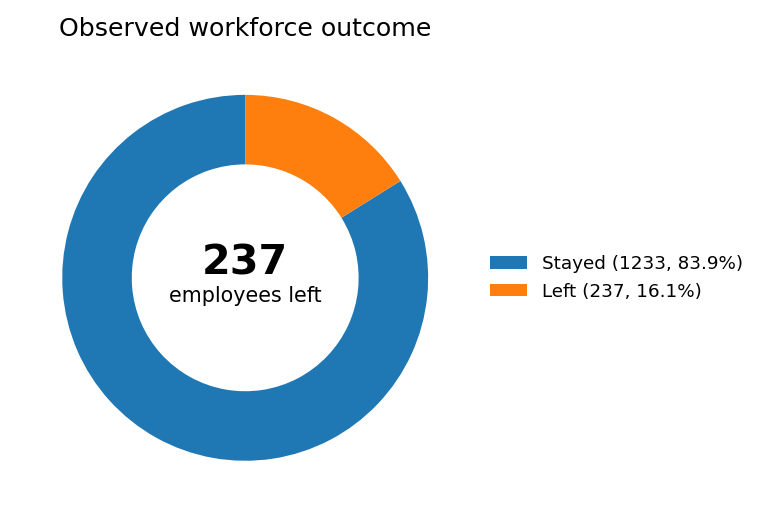


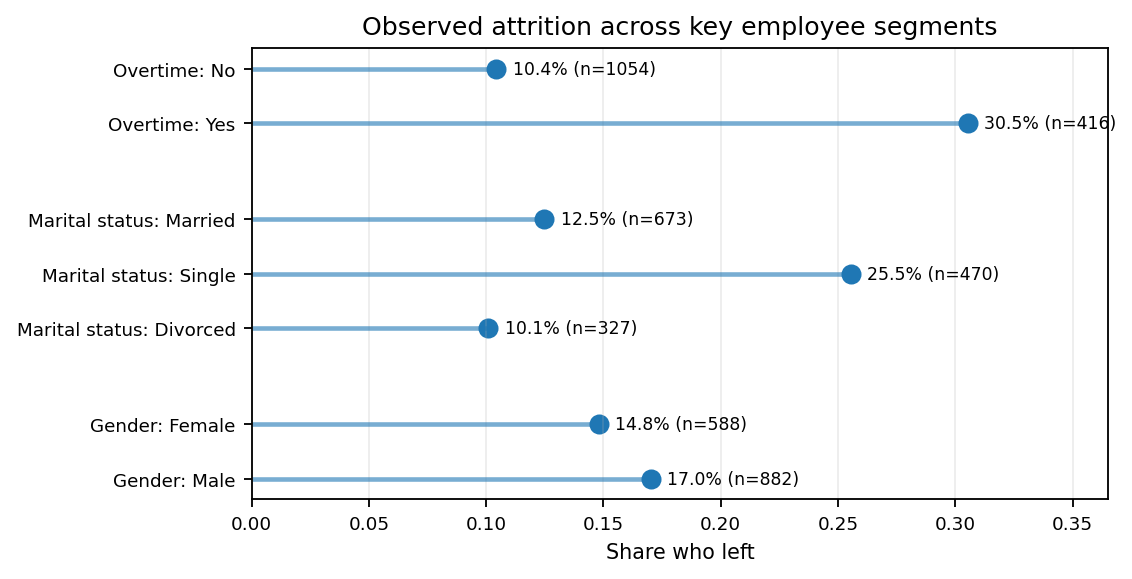


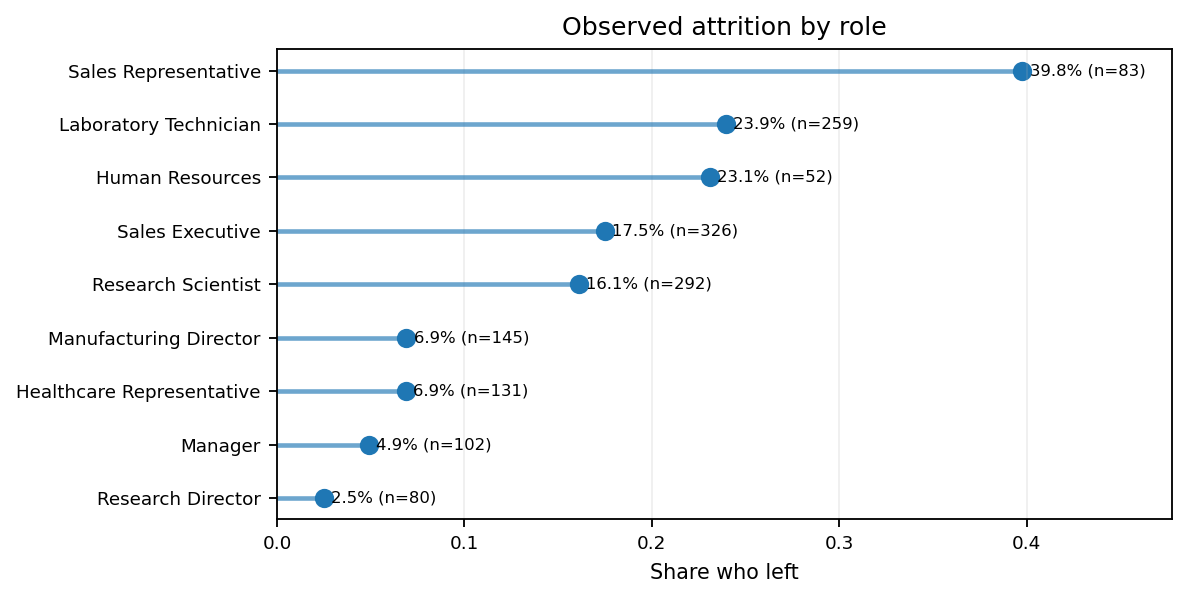


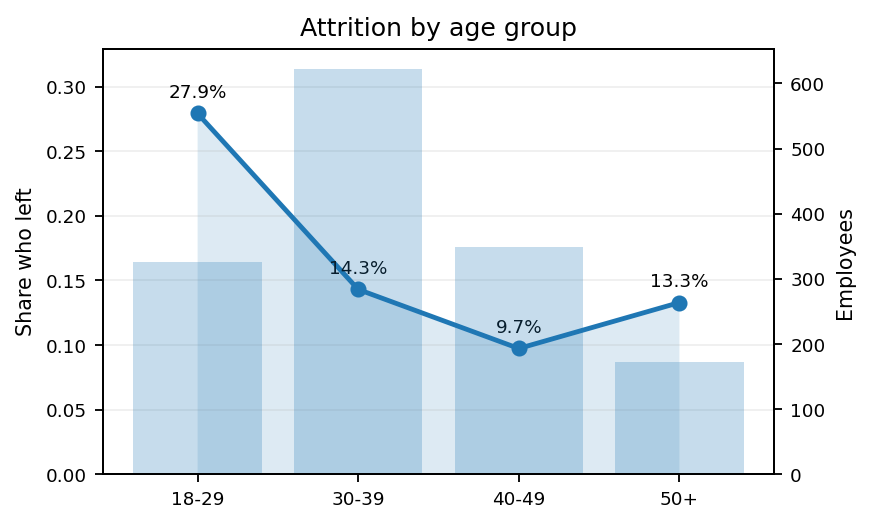


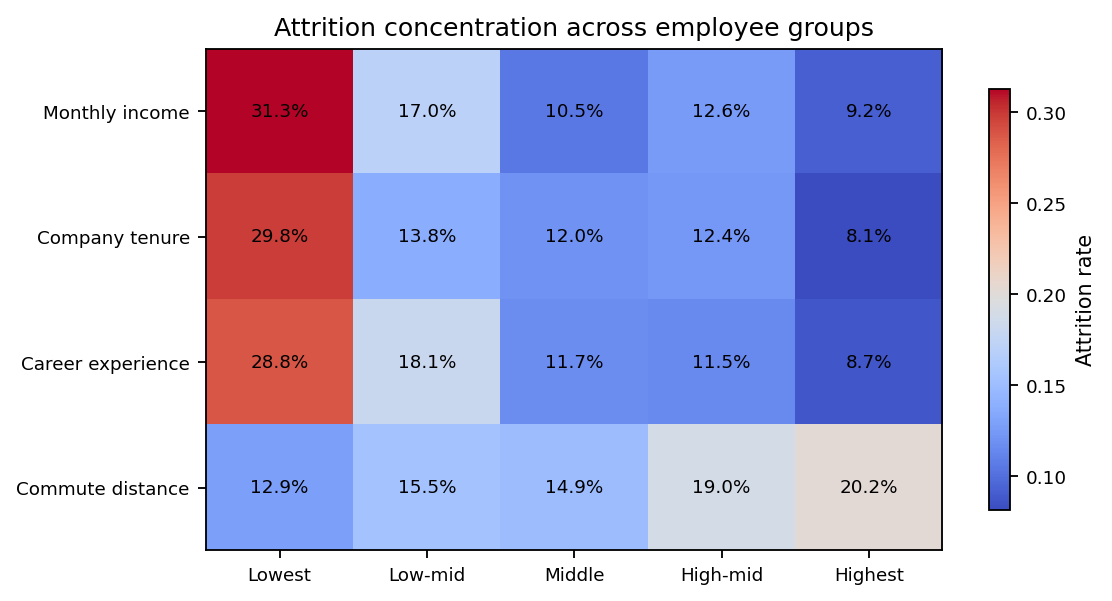


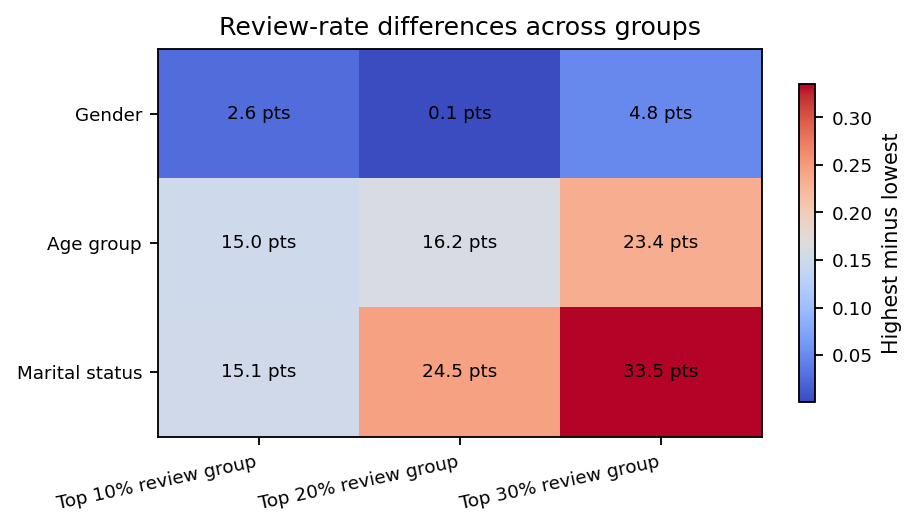

In [7]:
def show_report_image(key: str, title: str, caption: str):
    display(HTML(f"""
    <div style='border:1px solid #ddd; border-radius:10px; padding:12px; margin:10px 0; background:#fff'>
      <h3 style='margin:0 0 8px 0'>{title}</h3>
      <img src='data:image/png;base64,{images[key]}' style='max-width:100%; height:auto;'>
      <p style='color:#666; font-size:0.92em; margin:8px 0 0 0'>{caption}</p>
    </div>
    """))

show_report_image("outcome", "Observed workforce outcome", "Overall observed attrition in the supplied workforce dataset.")
show_report_image("segments", "Observed attrition across key employee segments", "Overtime, marital status, and gender segment comparisons.")
show_report_image("roles", "Observed attrition by role", "Role-level variation highlights organizational context that should be reviewed by workforce stakeholders.")
show_report_image("age", "Attrition by age group", "Age is retained for audit review, not scoring; younger employees show higher observed attrition in this dataset.")
show_report_image("numeric_view", "Attrition concentration across employee groups", "Quantile-based concentration view for income, tenure, experience, and commute distance.")
show_report_image("review_gap", "Review-rate differences across groups", "Sensitivity of review rates across gender, age group, and marital status under top-10%, top-20%, and top-30% policies.")


## 7. Transparent HUG-IML rule evidence

The pattern inventory is extracted from HUG-IML's feature-importance table and enriched with governance risk labels and stakeholder-facing audit interpretation notes.


In [8]:
rule_cols = ["pattern", "coefficient", "support", "abs_coefficient", "Direction", "Governance risk", "Audit interpretation"]
positive_rules = fi.sort_values("coefficient", ascending=False)[rule_cols].head(10).copy()
negative_rules = fi.sort_values("coefficient", ascending=True)[rule_cols].head(10).copy()

positive_rules["support"] = positive_rules["support"].map(lambda x: f"{100*x:.1f}%")
negative_rules["support"] = negative_rules["support"].map(lambda x: f"{100*x:.1f}%")

display(HTML("<h3>Rules associated with higher attrition-risk score</h3>"))
display(positive_rules)
display(HTML("<h3>Rules associated with lower attrition-risk score</h3>"))
display(negative_rules)


,pattern,coefficient,support,abs_coefficient,Direction,Governance risk,Audit interpretation
0,JobRole=Laboratory Technician,1.179793,17.7%,1.179793,Increases attrition-risk score,Medium,Role effects may reflect organizational condit...
1,"EnvironmentSatisfaction=[1,2)",1.092047,19.5%,1.092047,Increases attrition-risk score,Medium,Survey-derived sentiment is useful for support...
2,"TotalWorkingYears=[0,2)",1.086159,5.8%,1.086159,Increases attrition-risk score,Medium,Experience/tenure may proxy age or career stage.
3,EducationField=Human Resources,1.062640,1.8%,1.062640,Increases attrition-risk score,Medium,Education field may encode socioeconomic or oc...
4,"NumCompaniesWorked=[5,6)",1.062004,4.4%,1.062004,Increases attrition-risk score,Medium,"Mobility history may proxy age, career stage, ..."
6,"NumCompaniesWorked=[7,9)",0.977739,12.6%,0.977739,Increases attrition-risk score,Medium,"Mobility history may proxy age, career stage, ..."
9,"YearsWithCurrManager=[0,1)",0.886851,17.9%,0.886851,Increases attrition-risk score,Medium,Manager tenure may reflect organizational plac...
10,JobRole=Sales Executive,0.857122,23.2%,0.857122,Increases attrition-risk score,Medium,Role effects may reflect organizational condit...
12,"MonthlyIncome=[1009,2501)",0.817371,14.3%,0.817371,Increases attrition-risk score,High,Compensation is organizationally assigned and ...
14,"DistanceFromHome=[13.87,17)",0.770902,6.1%,0.770902,Increases attrition-risk score,Medium,"Commute distance may proxy geography, socioeco..."


,pattern,coefficient,support,abs_coefficient,Direction,Governance risk,Audit interpretation
5,OverTime=No,-1.039513,70.7%,1.039513,Lowers attrition-risk score,High,Overtime can reflect workload or managerial pr...
7,"StockOptionLevel=[1,3)",-0.941977,57.2%,0.941977,Lowers attrition-risk score,Medium,"Compensation structure may reflect level, role..."
8,JobRole=Research Director,-0.909240,5.2%,0.909240,Lowers attrition-risk score,Medium,Role effects may reflect organizational condit...
11,"NumCompaniesWorked=[0,1)",-0.843899,13.2%,0.843899,Lowers attrition-risk score,Medium,"Mobility history may proxy age, career stage, ..."
13,BusinessTravel=Non-Travel,-0.771451,10.9%,0.771451,Lowers attrition-risk score,Medium,Travel requirements may create caregiver/disab...
20,"DistanceFromHome=[1,2)",-0.663217,15.0%,0.663217,Lowers attrition-risk score,Medium,"Commute distance may proxy geography, socioeco..."
22,Department=Research & Development,-0.658740,64.9%,0.658740,Lowers attrition-risk score,Low,Standard job-context review; confirm business ...
25,"YearsWithCurrManager=[2,4)",-0.545963,32.9%,0.545963,Lowers attrition-risk score,Medium,Manager tenure may reflect organizational plac...
26,"JobLevel=[2,5)",-0.530429,64.8%,0.530429,Lowers attrition-risk score,High,Job level is linked to career-stage and compen...
28,"JobSatisfaction=[3,4)",-0.516836,61.1%,0.516836,Lowers attrition-risk score,Medium,Workplace sentiment should be used for support...


## 8. Group impact and threshold sensitivity

The audit frame evaluates review-routing policies that route the top 10%, top 20%, or top 30% of scored employees for attention. These should be interpreted as governance-review policies, not automated employment decisions.


In [9]:
threshold_display = threshold_tbl.copy()
for c in ["Highest review rate", "Lowest review rate", "Highest-lowest gap"]:
    threshold_display[c] = threshold_display[c].map(lambda x: f"{100*x:.1f}%")
threshold_display["Lowest / highest ratio"] = threshold_display["Lowest / highest ratio"].map(lambda x: f"{x:.2f}")

display(threshold_display)

for group in ["Gender", "AgeBand", "MaritalStatus"]:
    display(HTML(f"<h3>{group} — top 20% review policy</h3>"))
    tbl = group_table(audit, group, "review_top_20").copy()
    for c in ["actual_attrition_rate", "avg_risk_score", "review_rate", "miss_rate_among_actual_attriters", "review_rate_ratio_vs_max", "review_rate_gap_vs_min"]:
        tbl[c] = tbl[c].map(lambda x: f"{100*x:.1f}%" if pd.notna(x) else "n/a")
    display(tbl)


,Policy,Group,Highest review rate,Lowest review rate,Highest-lowest gap,Lowest / highest ratio
0,Top 10% review group,Gender,11.8%,9.2%,2.6%,0.78
1,Top 20% review group,Gender,20.2%,20.1%,0.1%,0.99
2,Top 30% review group,Gender,33.1%,28.3%,4.8%,0.85
3,Top 10% review group,Age group,20.0%,5.0%,15.0%,0.25
4,Top 20% review group,Age group,31.6%,15.4%,16.2%,0.49
5,Top 30% review group,Age group,47.4%,24.0%,23.4%,0.51
6,Top 10% review group,Marital status,19.2%,4.0%,15.1%,0.21
7,Top 20% review group,Marital status,35.6%,11.1%,24.5%,0.31
8,Top 30% review group,Marital status,50.7%,17.2%,33.5%,0.34


,Gender,employees,actual_attrition_rate,avg_risk_score,review_rate,miss_rate_among_actual_attriters,review_rate_ratio_vs_max,review_rate_gap_vs_min
1,Male,272,16.5%,14.8%,20.2%,44.4%,100.0%,0.1%
0,Female,169,15.4%,16.5%,20.1%,42.3%,99.5%,0.0%


,AgeBand,employees,actual_attrition_rate,avg_risk_score,review_rate,miss_rate_among_actual_attriters,review_rate_ratio_vs_max,review_rate_gap_vs_min
0,18-29,95,25.3%,25.2%,31.6%,33.3%,100.0%,16.2%
2,40-49,100,11.0%,11.0%,18.0%,36.4%,57.0%,2.6%
1,30-39,194,13.4%,14.2%,17.0%,50.0%,53.9%,1.6%
3,50+,52,19.2%,11.1%,15.4%,60.0%,48.7%,0.0%


,MaritalStatus,employees,actual_attrition_rate,avg_risk_score,review_rate,miss_rate_among_actual_attriters,review_rate_ratio_vs_max,review_rate_gap_vs_min
2,Single,146,24.7%,25.8%,35.6%,27.8%,100.0%,24.5%
1,Married,196,13.8%,11.3%,13.3%,63.0%,37.2%,2.2%
0,Divorced,99,8.1%,8.5%,11.1%,50.0%,31.2%,0.0%


## 9. Feature-use register

The register is generated from the supplied metadata and documents which columns are targets, excluded, audit-only, scoring candidates, or scoring-plus-review fields.


In [10]:
display(feature_register.head(25))

sensitive_feature_register = feature_register[
    feature_register["Status"].isin(["Audit-only", "Excluded", "Scoring + review"])
].copy()
display(HTML("<h3>Governance-sensitive fields shown in the HTML report</h3>"))
display(sensitive_feature_register)


,Feature,Status,Governance category,Audit treatment
0,Age,Audit-only,Protected/sensitive audit attribute,Employee age; excluded from scoring and retain...
2,BusinessTravel,Scoring + review,Medium proxy-risk / governance-sensitive,Business travel frequency; may reflect role de...
3,DailyRate,Scoring candidate,Business/HR context,Daily rate field; requires business justificat...
4,Department,Scoring candidate,Business/HR context,Department assignment; may reflect organizatio...
5,DistanceFromHome,Scoring + review,Medium proxy-risk / governance-sensitive,"Commute distance; may proxy geography, socioec..."
6,Education,Scoring candidate,Business/HR context,Education level; requires job-relatedness/busi...
7,EducationField,Scoring + review,Medium proxy-risk / governance-sensitive,Education field; may encode socioeconomic or o...
8,EmployeeCount,Excluded,Identifier/constant,Constant field; excluded from scoring.
9,EmployeeNumber,Excluded,Identifier/administrative,Employee identifier; excluded from scoring.
10,EnvironmentSatisfaction,Scoring + review,Medium proxy-risk / governance-sensitive,Survey-derived workplace sentiment; useful for...


,Feature,Status,Governance category,Audit treatment
0,Age,Audit-only,Protected/sensitive audit attribute,Employee age; excluded from scoring and retain...
2,BusinessTravel,Scoring + review,Medium proxy-risk / governance-sensitive,Business travel frequency; may reflect role de...
5,DistanceFromHome,Scoring + review,Medium proxy-risk / governance-sensitive,"Commute distance; may proxy geography, socioec..."
7,EducationField,Scoring + review,Medium proxy-risk / governance-sensitive,Education field; may encode socioeconomic or o...
8,EmployeeCount,Excluded,Identifier/constant,Constant field; excluded from scoring.
9,EmployeeNumber,Excluded,Identifier/administrative,Employee identifier; excluded from scoring.
10,EnvironmentSatisfaction,Scoring + review,Medium proxy-risk / governance-sensitive,Survey-derived workplace sentiment; useful for...
11,Gender,Audit-only,Protected/sensitive audit attribute,Gender; excluded from scoring and retained for...
13,JobInvolvement,Scoring + review,Workplace/assessment context,Workplace assessment; monitor for manager/team...
14,JobLevel,Scoring + review,High proxy-risk / governance-sensitive,Job level; linked to career stage and compensa...


## 10. Exported audit artifacts

The generated files are saved in the notebook directory. 


In [ ]:
artifact_table = pd.DataFrame([
    {"Artifact": p.name, "Path": str(p.resolve()), "Size bytes": p.stat().st_size}
    for p in [HTML_OUT, FEATURE_REGISTER_OUT, PATTERN_INVENTORY_OUT, THRESHOLD_SENSITIVITY_OUT]
])
display(artifact_table)

## 11. Governance interpretation notes

- The strongest observed split is overtime; this should be interpreted as a potential signal of workload, staffing pressure, scheduling design, or management practice rather than an individual fault signal.
- Audit-only fields such as age, gender, and marital status are useful for reviewing group differences but should remain outside scoring.
- Compensation, job level, tenure, role, travel, and satisfaction-related fields can be predictive but require business justification and careful employee-impact review.
- The top-k review policy materially affects group routing rates; the threshold-sensitivity table should therefore be reviewed before operational use.
- HUG-IML's transparent rules make the analysis auditable: each high-impact pattern can be reviewed for coverage, direction, business relevance, and governance sensitivity.
